### Model dry run with t cells from all ground truth crops
- use pretrained SAM3 tracks (have full cell type dict for these)

### Generate model inputs

In [1]:
import pickle
import numpy as np

import zipfile
from io import BytesIO
import tifffile

import os

from pathlib import Path
import yaml

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

from jax import vmap
from functools import partial

### Visualize emissions

In [2]:
emissions = np.load("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_emissions_array.npy")

In [3]:
reshaped_emissions = emissions.reshape(-1, emissions.shape[-1])  # [T*num_cells, num_features]
reshaped_emissions.shape, (50*528)

((26400, 3), 26400)

In [4]:
for i in range(5):
    kmeans = KMeans(n_clusters=i+2, random_state=0).fit(reshaped_emissions)
    score = silhouette_score(reshaped_emissions, kmeans.labels_)
    print(f"Silhouette Score for {i+2} clusters: {score:.4f}")

Silhouette Score for 2 clusters: 0.8695
Silhouette Score for 3 clusters: 0.7992
Silhouette Score for 4 clusters: 0.7715


KeyboardInterrupt: 

do a version with 2 clusters and a version with 3 clusters

In [6]:
kmeans_2_clusters = KMeans(n_clusters=2, random_state=0).fit(reshaped_emissions)
kmeans_3_clusters = KMeans(n_clusters=3, random_state=0).fit(reshaped_emissions)

In [8]:
pca = PCA(n_components=2)
pca_embeddings = pca.fit_transform(reshaped_emissions)
print(pca.explained_variance_ratio_)
print(np.sum(pca.explained_variance_ratio_))

[0.8923079  0.06252795]
0.9548358532590845


Text(0.5, 1.0, 'PCA of T Cell Emissions (3 Clusters)')

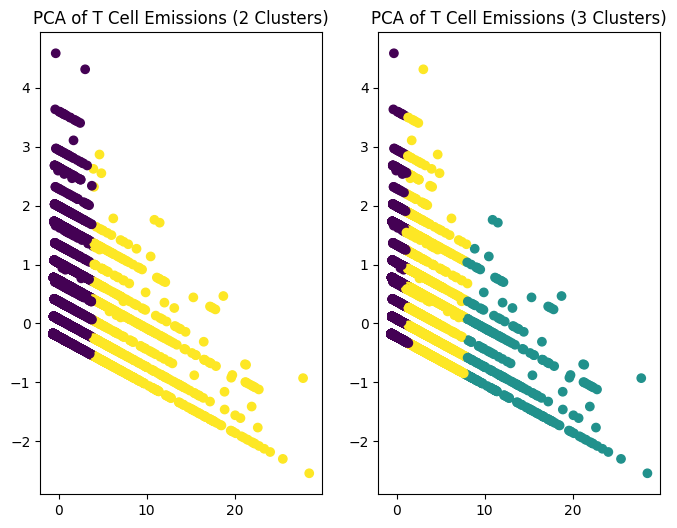

In [9]:
colors_2_clusters = kmeans_2_clusters.labels_
colors_3_clusters = kmeans_3_clusters.labels_

fig, ax = plt.subplots(1, 2, figsize=(8, 6))

ax[0].scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], c=colors_2_clusters, cmap='viridis')
ax[0].set_title("PCA of T Cell Emissions (2 Clusters)")

ax[1].scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], c=colors_3_clusters, cmap='viridis')
ax[1].set_title("PCA of T Cell Emissions (3 Clusters)")


### Initialize and run model

In [5]:
import sys
import os
import importlib

os.chdir("/gladstone/engelhardt/lab/jutran/lci/treeHMM")

import jax
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.stats import multivariate_normal

from utils import generate_tree_hmm_data
from utils import visualize_lineage

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from dynamax.hidden_markov_model import LinearAutoregressiveHMM
from models.tarhmm import tARHMM
from dynamax.utils.plotting import gradient_cmap
from dynamax.utils.utils import random_rotation
#from dynamax.hidden_markov_model.models.tarhmm import tree_hmm_backward_filter
from typing import Callable, Optional
from dynamax.types import IntScalar, Float, Array

# module import version sanity check
hasattr(jax.interpreters.xla, 'pytype_aval_mappings')

from models.tarhmm import tree_hmm_two_filter_smoother


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [6]:
num_states = list(range(2, 15))
emission_dim = 3
results = []

for state in num_states:
    num_states = state
    num_lags = 1

    transition_matrix = jnp.eye(num_states) * 0.85 + (1 - jnp.eye(num_states)) * 0.075

    emissions = np.load("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_emissions_array.npy")
    #emissions = emissions[:,:, 1:]

    with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_data.pkl", "rb") as f:
        data = pickle.load(f)
    
    with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_crop_and_cell_id_to_col.pkl", "rb") as f:
        crop_and_cell_id_to_col = pickle.load(f)

    arhmm = tARHMM(num_states, emission_dim, num_lags=num_lags)
    params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=emissions, transition_matrix = transition_matrix)
    inputs = vmap(arhmm.compute_inputs)(
        jnp.array(emissions),
        jnp.array(data["parent_indices"]),
        jnp.array(data["is_division_mask"]),
        jnp.array(data["is_new_root_mask"]),
        jnp.array(data["active_mask"]),
    )

    # TODO: maybe fix this???
    batched_emissions = emissions
    batched_inputs = inputs
    batched_parent_indices = data["parent_indices"]
    batched_is_division_mask = data["is_division_mask"]
    batched_active_mask = data["active_mask"]
    batched_is_new_root_mask = data["is_new_root_mask"]

    fitted_params, lps = arhmm.fit_em(params, props, batched_emissions, inputs=batched_inputs,
    parent_indices=batched_parent_indices,
    is_division_mask=batched_is_division_mask,
    active_mask=batched_active_mask,
    is_new_root_mask=batched_is_new_root_mask)

    results.append((np.mean(lps), lps))

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

...

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:02&lt;00:00]</div>

In [7]:
emissions.shape

(6, 50, 88, 3)

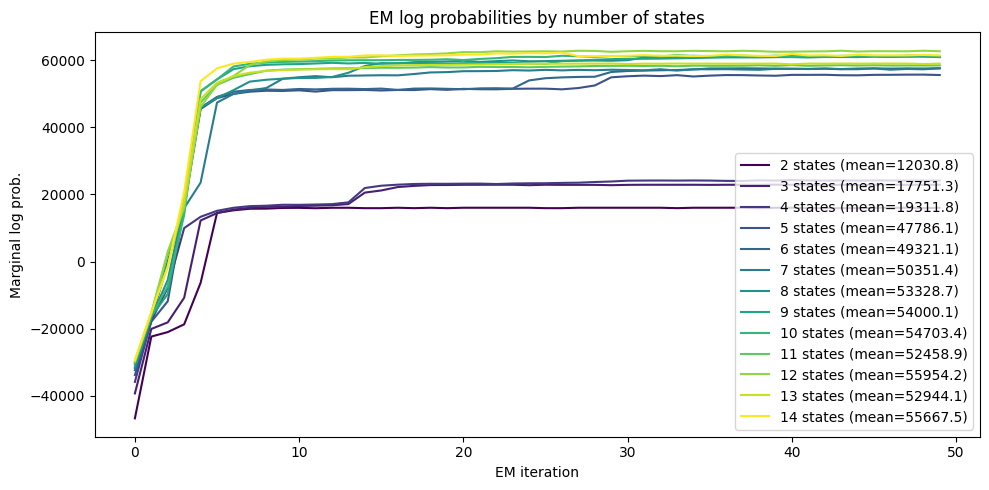

In [9]:
state_range = list(range(2, 15))
cmap = plt.cm.viridis
colors = [cmap(i / (len(state_range) - 1)) for i in range(len(state_range))]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (mean_lp, lps) in enumerate(results[:len(state_range)]):
    n = state_range[i]
    ax.plot(lps, color=colors[i], label=f"{n} states (mean={mean_lp:.1f})")

ax.set_xlabel("EM iteration")
ax.set_ylabel("Marginal log prob.")
ax.set_title("EM log probabilities by number of states")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [29]:
num_states = [5]

for state in num_states:
    num_states = state
    emission_dim = 3
    num_lags = 1

    transition_matrix = jnp.eye(state) * 0.85 + (1 - jnp.eye(state)) * 0.075

    emissions = np.load("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_emissions_array.npy")
    #emissions = emissions[:,:, 1:]

    with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_data.pkl", "rb") as f:
        data = pickle.load(f)
    
    with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_crop_and_cell_id_to_col.pkl", "rb") as f:
        crop_and_cell_id_to_col = pickle.load(f)

    arhmm = tARHMM(num_states, emission_dim, num_lags=num_lags)
    params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=emissions, transition_matrix = transition_matrix)
    inputs = vmap(arhmm.compute_inputs)(
        jnp.array(emissions),
        jnp.array(data["parent_indices"]),
        jnp.array(data["is_division_mask"]),
        jnp.array(data["is_new_root_mask"]),
        jnp.array(data["active_mask"]),
    )

    # TODO: maybe fix this???
    batched_emissions = emissions
    batched_inputs = inputs
    batched_parent_indices = data["parent_indices"]
    batched_is_division_mask = data["is_division_mask"]
    batched_active_mask = data["active_mask"]
    batched_is_new_root_mask = data["is_new_root_mask"]

    fitted_params, lps = arhmm.fit_em(params, props, batched_emissions, inputs=batched_inputs,
    parent_indices=batched_parent_indices,
    is_division_mask=batched_is_division_mask,
    active_mask=batched_active_mask,
    is_new_root_mask=batched_is_new_root_mask)

    # Compute the posterior distribution of the latent states
    #input_fwd = arhmm._inference_args(params, emissions, inputs, data['parent_indices'], data['is_division_mask'], data['active_mask'],data['is_new_root_mask'])
    input_fwd = vmap(partial(arhmm._inference_args, fitted_params))(emissions, inputs, data['parent_indices'], data['is_division_mask'], data['active_mask'],data['is_new_root_mask'])
    posterior = vmap(tree_hmm_two_filter_smoother)(*input_fwd)

    # save state assignments
    state_assignments = jnp.argmax(posterior.smoothed_probs, axis=-1)  # (50, 110)

    data_output_dir = "/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/"
    np.save(os.path.join(data_output_dir, f"batched_state_assignments_{num_states}_states.npy"), state_assignments)

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

In [11]:
state_assignments.shape

(6, 50, 88)

In [ ]:
# emissions[:,:, 1:]

(50, 326, 2)

### Visualize outputs

In [13]:
# max_probs = jnp.max(posterior.smoothed_probs, axis=-1)  # (50, 326)

# fig, ax = plt.subplots(figsize=(12, 8))
# im = ax.imshow(max_probs.T, aspect="auto", interpolation="none", cmap="viridis", origin="upper", vmin=0, vmax=1)
# ax.set_xlabel("Time")
# ax.set_ylabel("Cell")
# ax.set_title("Max Smoothed Probability")
# cbar = plt.colorbar(im, ax=ax)
# cbar.set_label("Probability")
# plt.tight_layout()
# plt.show()

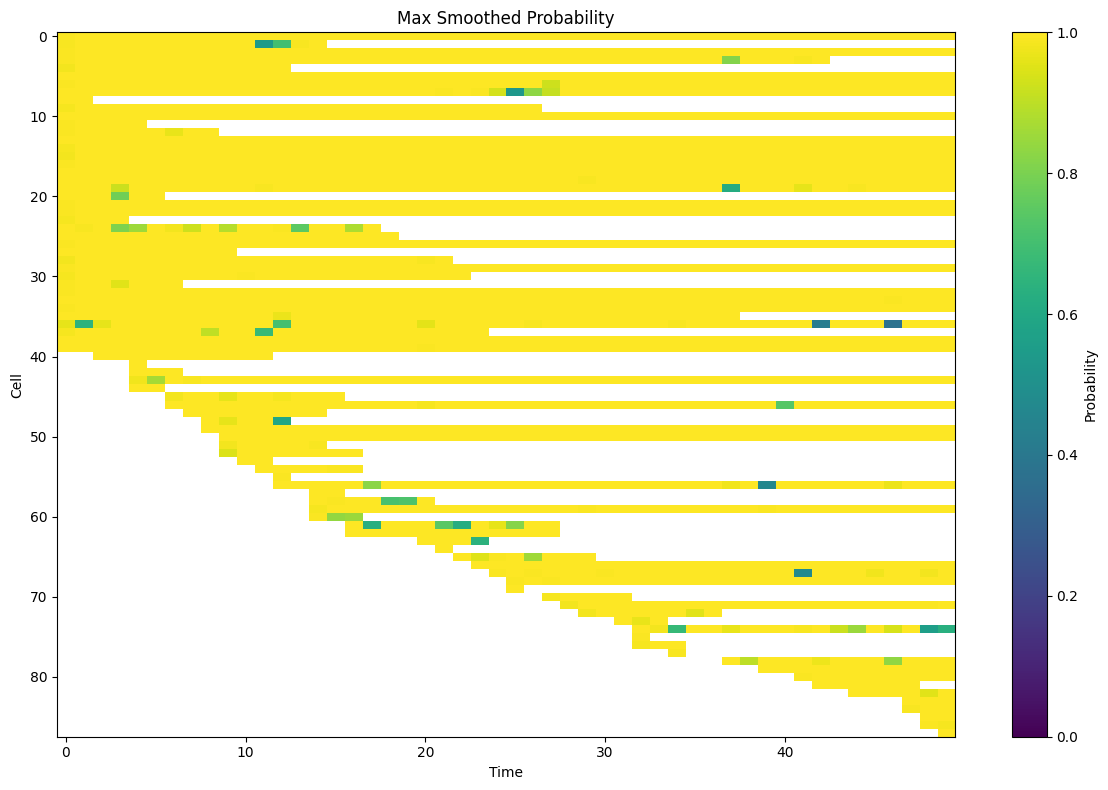

In [22]:
max_probs = jnp.max(posterior.smoothed_probs, axis=-1)  # (50, 326)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(max_probs[4].T, aspect="auto", interpolation="none", cmap="viridis", origin="upper", vmin=0, vmax=1)
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("Max Smoothed Probability")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probability")
plt.tight_layout()
plt.show()

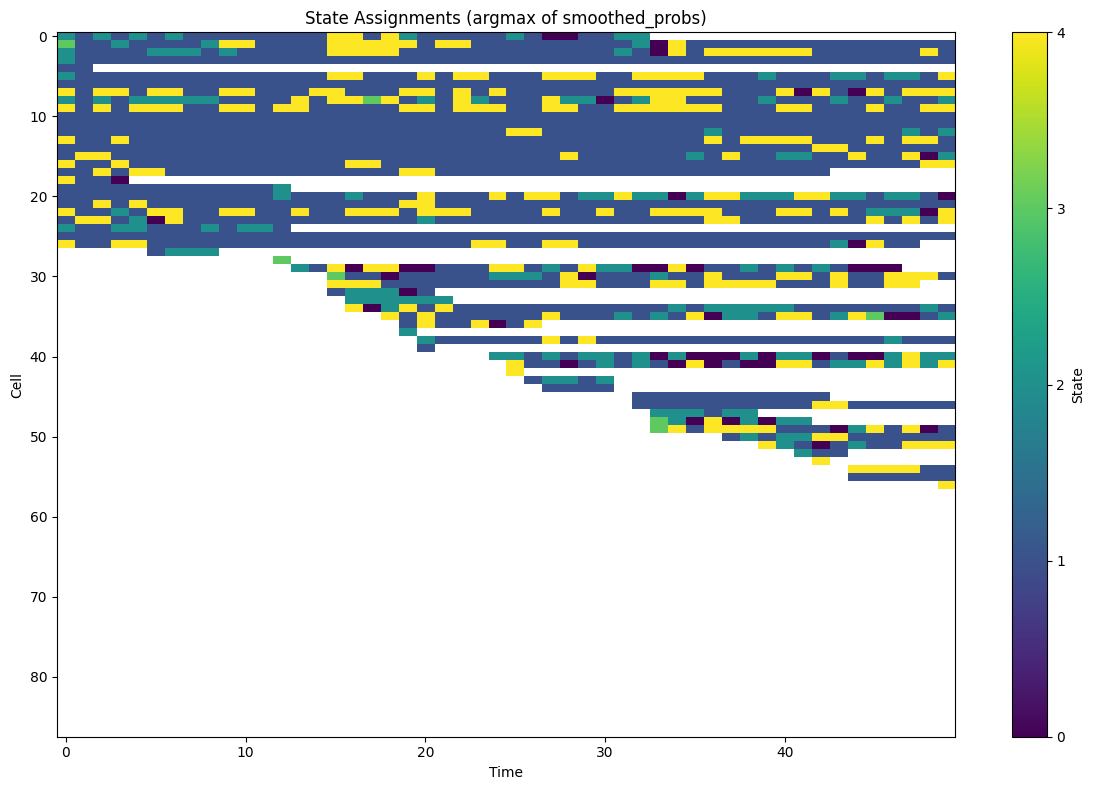

In [30]:
well_idx = 0
masked_state_assignments = jnp.where(jnp.isnan(max_probs[well_idx].T), jnp.nan, state_assignments[well_idx].T)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(masked_state_assignments, aspect="auto", interpolation="none", cmap="viridis", origin="upper")
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("State Assignments (argmax of smoothed_probs)")
cbar = plt.colorbar(im, ax=ax, ticks=range(num_states))
cbar.set_label("State")
plt.tight_layout()
plt.show()

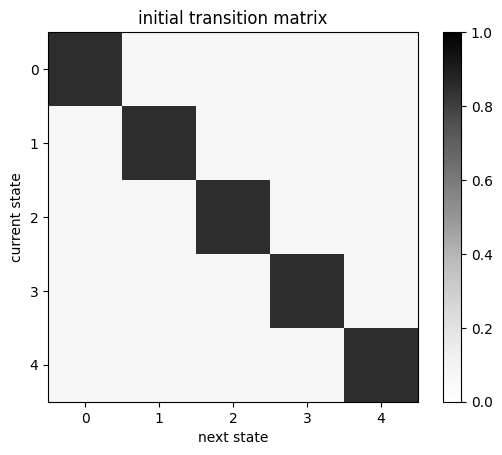

In [27]:
initial_transitions = params.transitions.transition_matrix
plt.imshow(initial_transitions, vmin=0, vmax=1, cmap="Greys")
plt.xlabel("next state")
plt.ylabel("current state")
plt.title("initial transition matrix")
plt.colorbar()

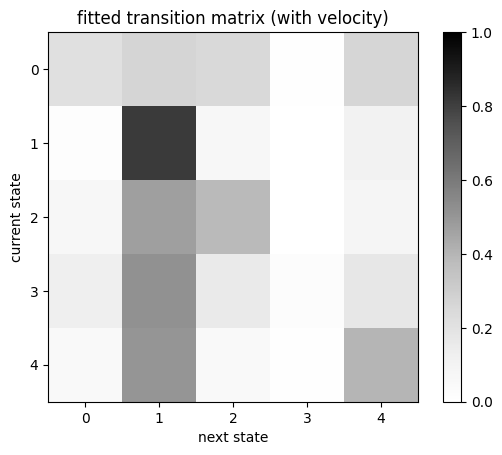

In [28]:
fitted_transitions = fitted_params.transitions.transition_matrix
plt.imshow(fitted_transitions, vmin=0, vmax=1, cmap="Greys")
plt.xlabel("next state")
plt.ylabel("current state")
plt.title("fitted transition matrix (with velocity)")
plt.colorbar()

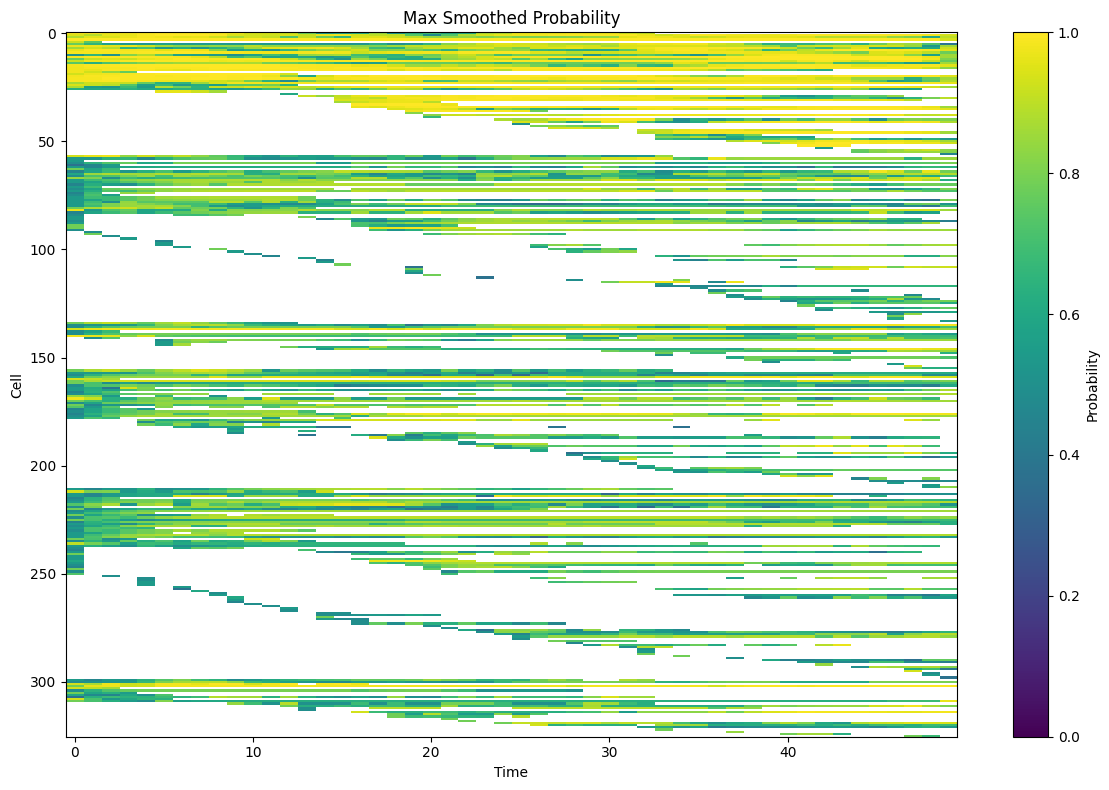

In [28]:
max_probs = jnp.max(posterior.smoothed_probs, axis=-1)  # (50, 326)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(max_probs.T, aspect="auto", interpolation="none", cmap="viridis", origin="upper", vmin=0, vmax=1)
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("Max Smoothed Probability")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probability")
plt.tight_layout()
plt.show()

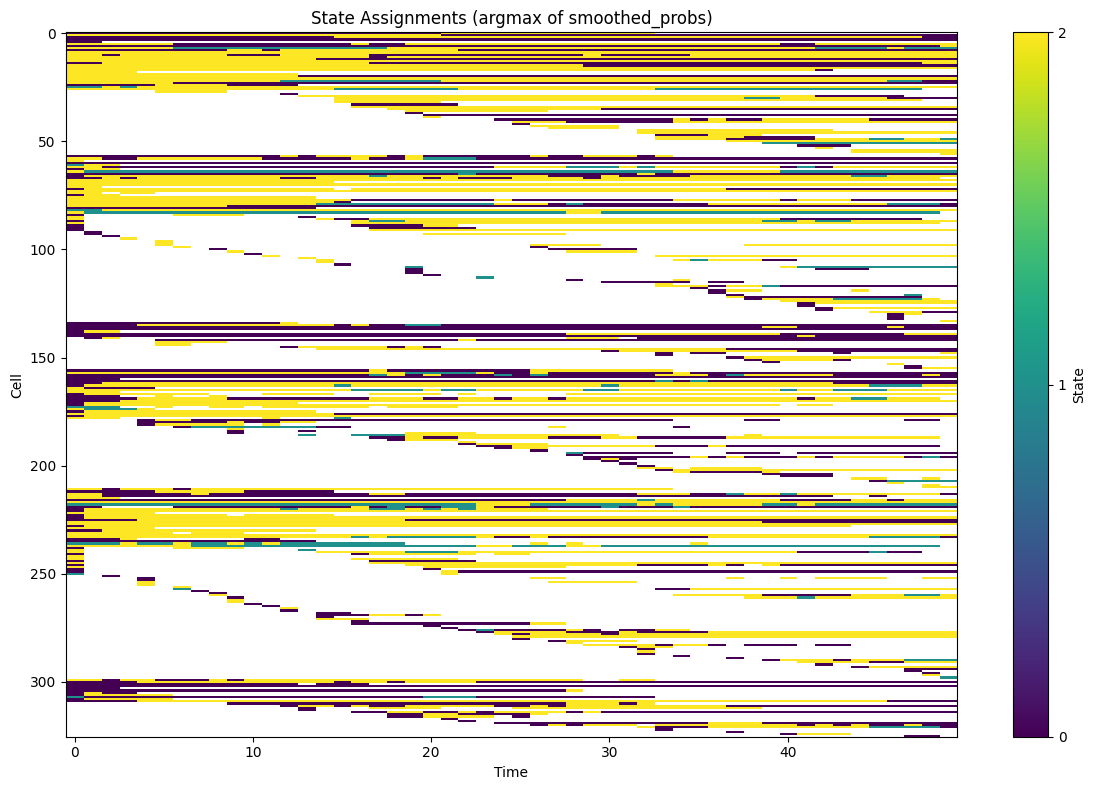

In [29]:
masked_state_assignments = jnp.where(jnp.isnan(max_probs.T), jnp.nan, state_assignments.T)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(masked_state_assignments, aspect="auto", interpolation="none", cmap="viridis", origin="upper")
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("State Assignments (argmax of smoothed_probs)")
cbar = plt.colorbar(im, ax=ax, ticks=range(num_states))
cbar.set_label("State")
plt.tight_layout()
plt.show()

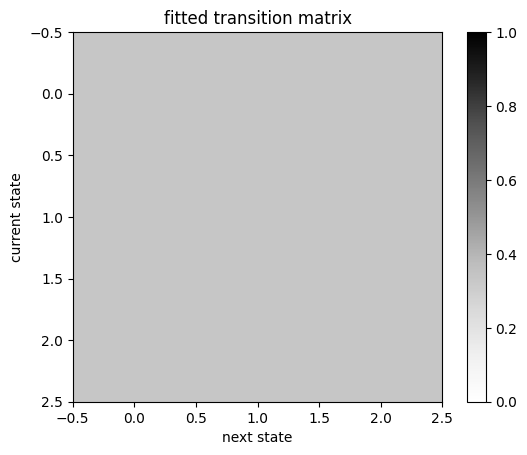

In [25]:
fitted_transitions = fitted_params.transitions.transition_matrix
plt.imshow(fitted_transitions, vmin=0, vmax=1, cmap="Greys")
plt.xlabel("next state")
plt.ylabel("current state")
plt.title("fitted transition matrix")
plt.colorbar()

### New Visualizations (04/20/2026 batching)

In [20]:
posterior.smoothed_probs.shape

(6, 50, 88, 3)

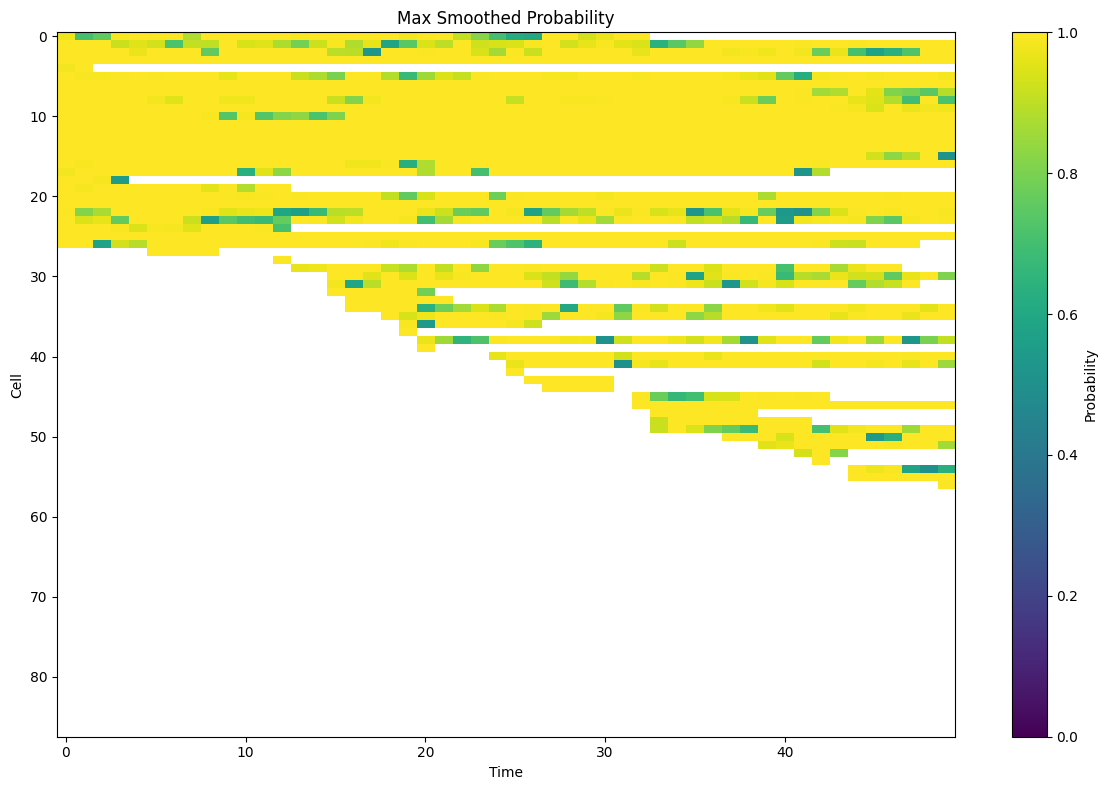

In [21]:
max_probs = jnp.max(posterior.smoothed_probs[0], axis=-1)  # (50, 326)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(max_probs.T, aspect="auto", interpolation="none", cmap="viridis", origin="upper", vmin=0, vmax=1)
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("Max Smoothed Probability")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probability")
plt.tight_layout()
plt.show()

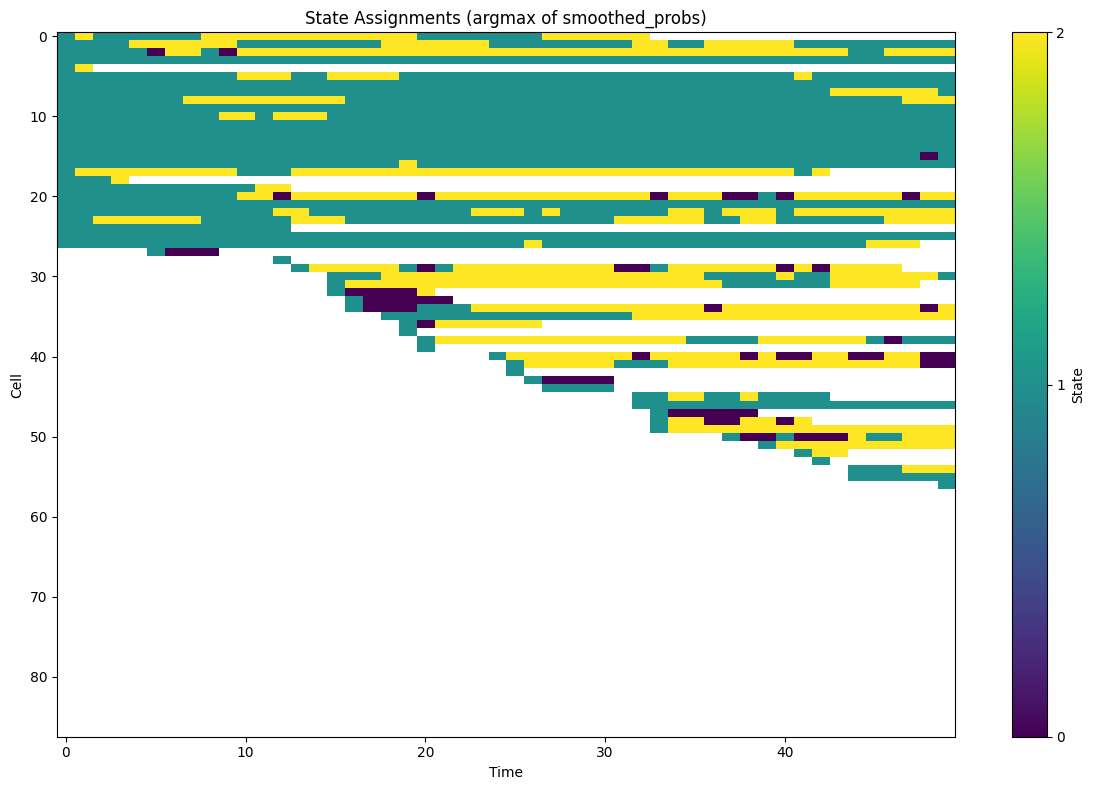

In [22]:
masked_state_assignments = jnp.where(jnp.isnan(max_probs.T), jnp.nan, state_assignments[0].T)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(masked_state_assignments, aspect="auto", interpolation="none", cmap="viridis", origin="upper")
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("State Assignments (argmax of smoothed_probs)")
cbar = plt.colorbar(im, ax=ax, ticks=range(num_states))
cbar.set_label("State")
plt.tight_layout()
plt.show()

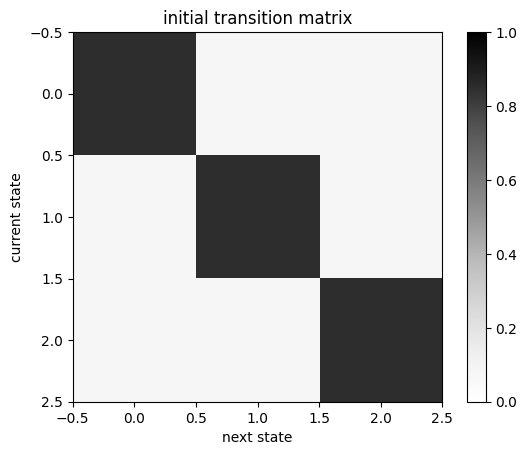

In [23]:
initial_transitions = params.transitions.transition_matrix
plt.imshow(initial_transitions, vmin=0, vmax=1, cmap="Greys")
plt.xlabel("next state")
plt.ylabel("current state")
plt.title("initial transition matrix")
plt.colorbar()

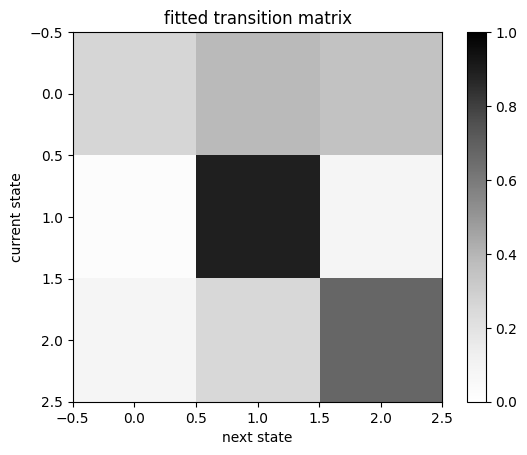

In [24]:
fitted_transitions = fitted_params.transitions.transition_matrix
plt.imshow(fitted_transitions, vmin=0, vmax=1, cmap="Greys")
plt.xlabel("next state")
plt.ylabel("current state")
plt.title("fitted transition matrix")
plt.colorbar()

### run model on only one well

In [2]:
emissions = np.load("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_emissions_array.npy")
#emissions = emissions[:,:, 1:]

with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_data.pkl", "rb") as f:
    data = pickle.load(f)

with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_crop_and_cell_id_to_col.pkl", "rb") as f:
    crop_and_cell_id_to_col = pickle.load(f)

In [40]:
num_states = [3]

for state in num_states:
    num_states = state
    emission_dim = 3
    num_lags = 1

    transition_matrix = jnp.eye(3) * 0.85 + (1 - jnp.eye(3)) * 0.075

    emissions = np.load("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_emissions_array.npy")
    #emissions = emissions[:,:, 1:]

    with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_data.pkl", "rb") as f:
        data = pickle.load(f)
    
    with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_crop_and_cell_id_to_col.pkl", "rb") as f:
        crop_and_cell_id_to_col = pickle.load(f)

    arhmm = tARHMM(num_states, emission_dim, num_lags=num_lags)
    params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=emissions, transition_matrix = transition_matrix)
    inputs = vmap(arhmm.compute_inputs)(
        jnp.array(emissions),
        jnp.array(data["parent_indices"]),
        jnp.array(data["is_division_mask"]),
        jnp.array(data["is_new_root_mask"]),
        jnp.array(data["active_mask"]),
    )

    # TODO: maybe fix this???
    batched_emissions = emissions[0]
    batched_inputs = inputs[0]
    batched_parent_indices = data["parent_indices"][0]
    batched_is_division_mask = data["is_division_mask"][0]
    batched_active_mask = data["active_mask"][0]
    batched_is_new_root_mask = data["is_new_root_mask"][0]

    fitted_params, lps = arhmm.fit_em(params, props, batched_emissions, inputs=batched_inputs,
    parent_indices=batched_parent_indices,
    is_division_mask=batched_is_division_mask,
    active_mask=batched_active_mask,
    is_new_root_mask=batched_is_new_root_mask)

    # Compute the posterior distribution of the latent states
    #input_fwd = arhmm._inference_args(params, emissions, inputs, data['parent_indices'], data['is_division_mask'], data['active_mask'],data['is_new_root_mask'])

    input_fwd = arhmm._inference_args(params, emissions[0], inputs[0], data['parent_indices'][0], data['is_division_mask'][0], data['active_mask'][0],data['is_new_root_mask'][0])
    posterior = tree_hmm_two_filter_smoother(*input_fwd)

    # save state assignments
    state_assignments = jnp.argmax(posterior.smoothed_probs, axis=-1)  # (50, 110)

    # data_output_dir = "/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/"
    # np.save(os.path.join(data_output_dir, f"batched_state_assignments_{num_states}_states.npy"), state_assignments)

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:02&lt;00:00]</div>

In [41]:
state_assignments.shape

(50, 88)

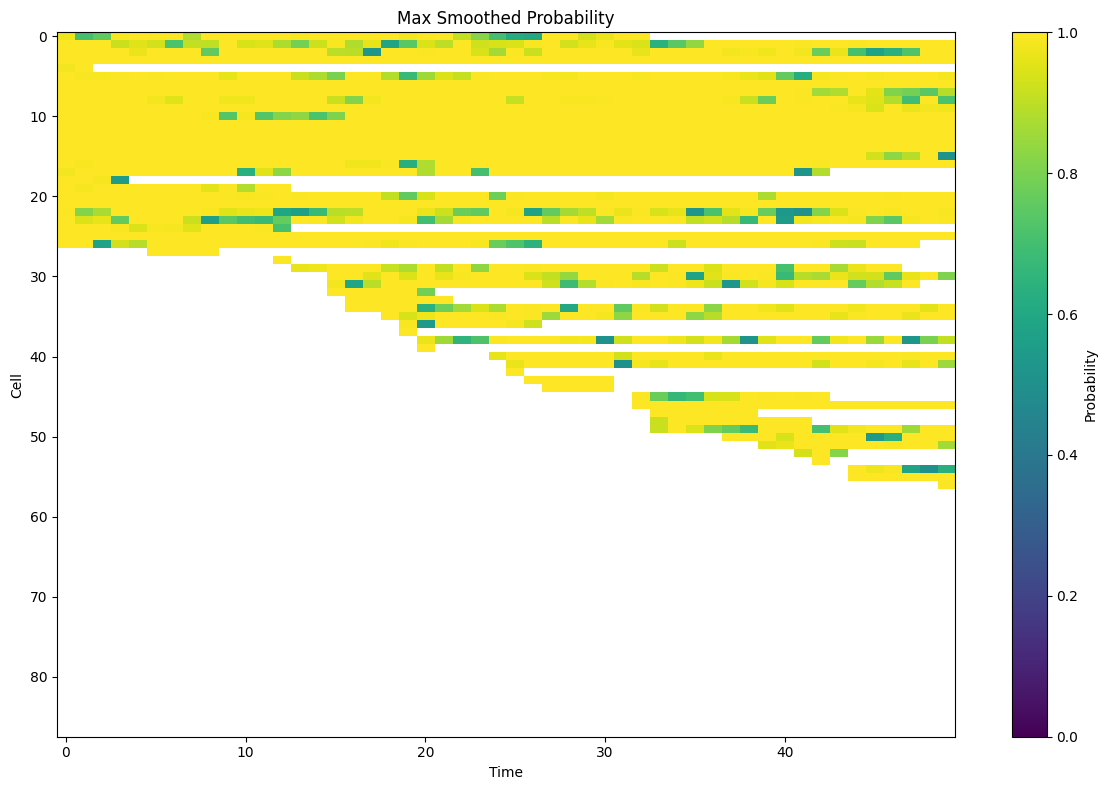

In [42]:
max_probs = jnp.max(posterior.smoothed_probs, axis=-1)  # (50, 326)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(max_probs.T, aspect="auto", interpolation="none", cmap="viridis", origin="upper", vmin=0, vmax=1)
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("Max Smoothed Probability")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probability")
plt.tight_layout()
plt.show()

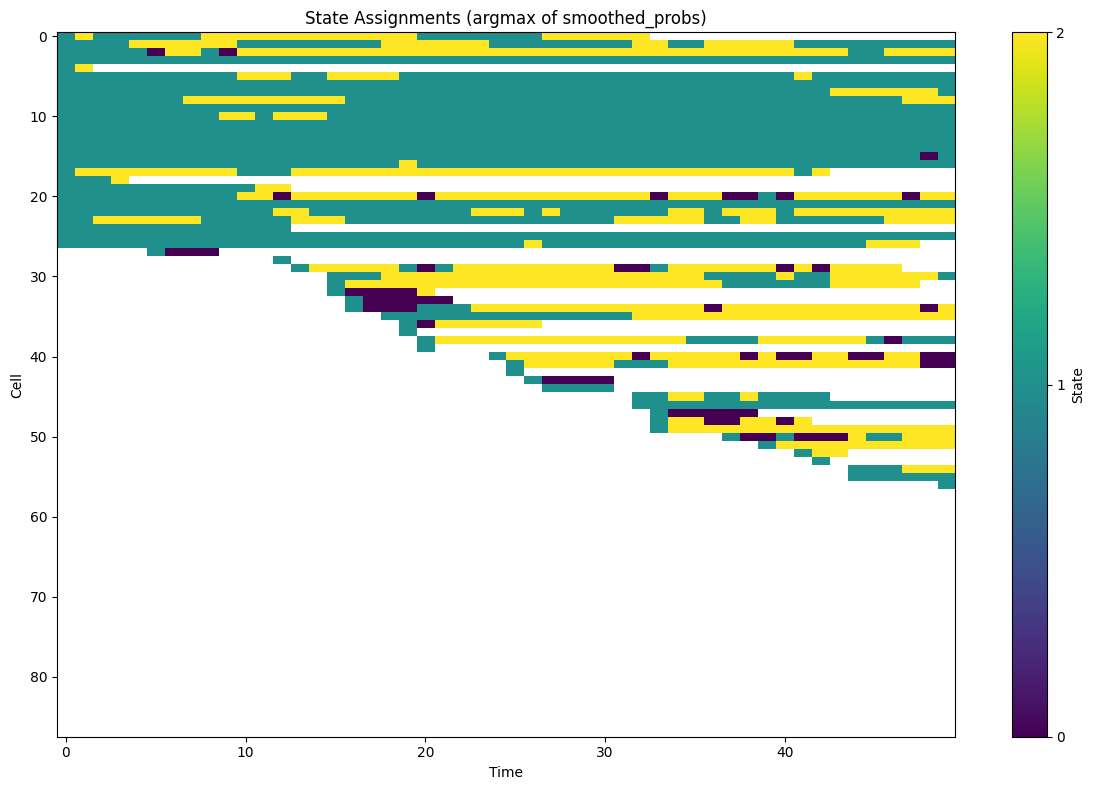

In [43]:
masked_state_assignments = jnp.where(jnp.isnan(max_probs.T), jnp.nan, state_assignments.T)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(masked_state_assignments, aspect="auto", interpolation="none", cmap="viridis", origin="upper")
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("State Assignments (argmax of smoothed_probs)")
cbar = plt.colorbar(im, ax=ax, ticks=range(num_states))
cbar.set_label("State")
plt.tight_layout()
plt.show()

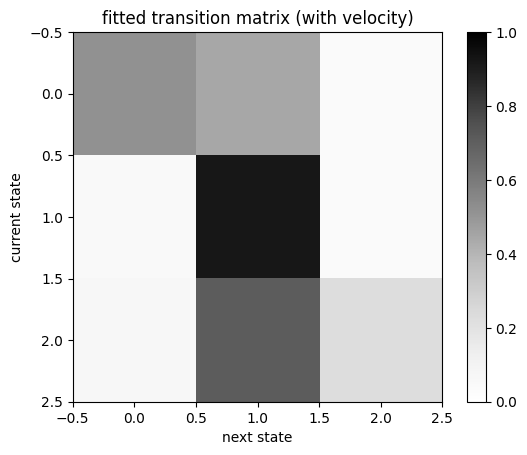

In [44]:
fitted_transitions = fitted_params.transitions.transition_matrix
plt.imshow(fitted_transitions, vmin=0, vmax=1, cmap="Greys")
plt.xlabel("next state")
plt.ylabel("current state")
plt.title("fitted transition matrix (with velocity)")
plt.colorbar()

### try getting all the lps

In [ ]:
import sys
import os
import importlib

os.chdir("/gladstone/engelhardt/lab/jutran/lci/treeHMM")

import jax
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.stats import multivariate_normal

from utils import generate_tree_hmm_data
from utils import visualize_lineage

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from dynamax.hidden_markov_model import LinearAutoregressiveHMM
from models.tarhmm import tARHMM
from dynamax.utils.plotting import gradient_cmap
from dynamax.utils.utils import random_rotation
#from dynamax.hidden_markov_model.models.tarhmm import tree_hmm_backward_filter
from typing import Callable, Optional
from dynamax.types import IntScalar, Float, Array

# module import version sanity check
hasattr(jax.interpreters.xla, 'pytype_aval_mappings')

from models.tarhmm import tree_hmm_two_filter_smoother


In [5]:
num_states = list(range(2, 10))
results = []

for state in num_states:
    num_states = state
    emission_dim = 3
    num_lags = 1

    transition_matrix = jnp.eye(num_states) * 0.85 + (1 - jnp.eye(num_states)) * 0.075

    emissions = np.load("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_emissions_array.npy")
    #emissions = emissions[:,:, 1:]

    with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_data.pkl", "rb") as f:
        data = pickle.load(f)
    
    with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/batched_crop_and_cell_id_to_col.pkl", "rb") as f:
        crop_and_cell_id_to_col = pickle.load(f)

    arhmm = tARHMM(num_states, emission_dim, num_lags=num_lags)
    params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=emissions, transition_matrix = transition_matrix)
    inputs = vmap(arhmm.compute_inputs)(
        jnp.array(emissions),
        jnp.array(data["parent_indices"]),
        jnp.array(data["is_division_mask"]),
        jnp.array(data["is_new_root_mask"]),
        jnp.array(data["active_mask"]),
    )

    # TODO: maybe fix this???
    batched_emissions = emissions
    batched_inputs = inputs
    batched_parent_indices = data["parent_indices"]
    batched_is_division_mask = data["is_division_mask"]
    batched_active_mask = data["active_mask"]
    batched_is_new_root_mask = data["is_new_root_mask"]

    fitted_params, lps = arhmm.fit_em(params, props, batched_emissions, inputs=batched_inputs,
    parent_indices=batched_parent_indices,
    is_division_mask=batched_is_division_mask,
    active_mask=batched_active_mask,
    is_new_root_mask=batched_is_new_root_mask)

    results.append((np.mean(lps), lps))

    # # Compute the posterior distribution of the latent states
    # #input_fwd = arhmm._inference_args(params, emissions, inputs, data['parent_indices'], data['is_division_mask'], data['active_mask'],data['is_new_root_mask'])

    # input_fwd = arhmm._inference_args(params, emissions[0], inputs[0], data['parent_indices'][0], data['is_division_mask'][0], data['active_mask'][0],data['is_new_root_mask'][0])
    # posterior = tree_hmm_two_filter_smoother(*input_fwd)

    # # save state assignments
    # state_assignments = jnp.argmax(posterior.smoothed_probs, axis=-1)  # (50, 110)

    # # data_output_dir = "/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/"
    # # np.save(os.path.join(data_output_dir, f"batched_state_assignments_{num_states}_states.npy"), state_assignments)

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

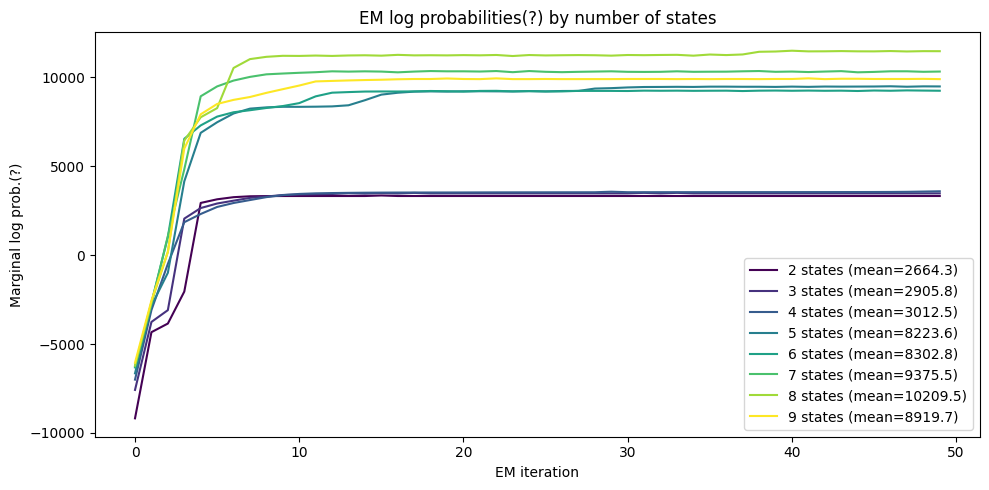

In [55]:
state_range = list(range(2, 10))
cmap = plt.cm.viridis
colors = [cmap(i / (len(state_range) - 1)) for i in range(len(state_range))]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (mean_lp, lps) in enumerate(results):
    n = state_range[i]
    ax.plot(lps, color=colors[i], label=f"{n} states (mean={mean_lp:.1f})")

ax.set_xlabel("EM iteration")
ax.set_ylabel("Marginal log prob.(?)")
ax.set_title("EM log probabilities(?) by number of states")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

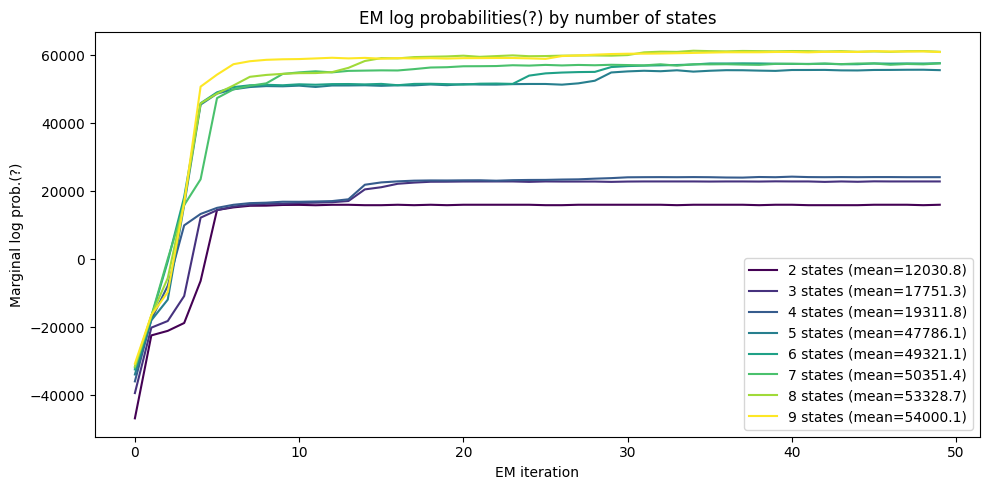

In [6]:
state_range = list(range(2, 10))
cmap = plt.cm.viridis
colors = [cmap(i / (len(state_range) - 1)) for i in range(len(state_range))]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (mean_lp, lps) in enumerate(results):
    n = state_range[i]
    ax.plot(lps, color=colors[i], label=f"{n} states (mean={mean_lp:.1f})")

ax.set_xlabel("EM iteration")
ax.set_ylabel("Marginal log prob.(?)")
ax.set_title("EM log probabilities(?) by number of states")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()